# Chapter 13 (extra) — The square scheme: three ways to handle the cross reaction

*Companion to [Chapter 13 — Coupled Chemical Reactions](../13_coupled_chemical_reactions.ipynb).
A Python adaptation of the square-scheme section of Michael Honeychurch,
**Simulating Electrochemical Reactions in Mathematica** (SERM), Chapter 13
(`Chapters/chapter13.nb`) and the standalone notebooks `SquareRxnExp1.nb`,
`SquareRxnExp2.nb`, `SquareRxnExp3.nb`.*

A **square scheme** is the canonical motif for an electron transfer whose product
chemically rearranges into a form that is *itself* electroactive. Two one-electron
couples are linked by chemical interconversion of both the oxidised and the reduced
partners, and closed by a homogeneous **cross reaction**:

$$
\begin{array}{ccc}
\mathrm{O} + e^- & \rightleftharpoons & \mathrm{R}\\[2pt]
\updownarrow{\scriptstyle k_{+1},k_{-1}} & & \updownarrow{\scriptstyle k_{+2},k_{-2}}\\[2pt]
\mathrm{A} + e^- & \rightleftharpoons & \mathrm{B}
\end{array}
\qquad\qquad
\mathrm{O} + \mathrm{B} \;\rightleftharpoons[\,k_{cb}\,]{\,k_{cf}\,}\; \mathrm{R} + \mathrm{A}.
$$

The two electrode couples ($\mathrm{O/R}$ at $E^0_{OR}$, $\mathrm{A/B}$ at
$E^0_{AB}$) share the same sweep, so the surface ratios are
$\xi_1=\exp[\tfrac{nF}{RT}(E-E^0_{OR})]$ and $\xi_2=\exp[\tfrac{nF}{RT}(E-E^0_{AB})]$.
Four solution species couple at every node, so Rudolph's block-tridiagonal trick
(used throughout Chapter 13) now carries **$4\times4$ blocks**.

The first four reactions are *first order* and enter the implicit matrix linearly,
through a constant kinetics block. The **cross reaction is bimolecular**, so the
discrete equations are *non-linear* in the unknown $(k\!+\!1)$-level
concentrations. This notebook builds three solvers of increasing fidelity, all
re-using `serm.ch13_square_scheme`:

1. **cross-term ignored** ($k_{cf}=k_{cb}=0$) — linear, one banded solve/step;
2. **linearised** — keep the cross reaction but expand it about the previous time
   level, dropping the second-order $\delta c\,\delta c$ term (Honeychurch's linear
   approximation);
3. **Newton–Raphson** — solve the full non-linear step exactly, assembling the
   analytic $4\times4$ Jacobian blocks and iterating the banded solve.

Throughout, the species order is $0=\mathrm{O},\,1=\mathrm{R},\,2=\mathrm{A},\,3=\mathrm{B}$,
the grid is uniform, and the electrode boundary is Nernstian for both couples
(a Nernst-ratio equation plus a zero-net-flux equation per couple), exactly as in
the chapter notebook.

In [1]:
import os, sys
# This notebook lives in notebooks/extras/, so walk up to the repo root (the
# directory that contains the `serm` package) and put it on sys.path.
_root = os.getcwd()
while not os.path.isdir(os.path.join(_root, "serm")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)

# %matplotlib inline embeds figures and makes plt.show() harmless under headless (Agg)
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from serm import ch13_square_scheme as sq
from serm import ch05_potential_sweep_reversible as ch05

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# Show the constant 4x4 kinetics block that encodes O<->A and R<->B interconversion.
demo = sq.SquareParams(k_plus1=0.05, k_minus1=0.02, k_plus2=0.03, k_minus2=0.04)
print("constant kinetics block K (rows = net loss of O,R,A,B):")
print(sq._const_kinetics_block(demo))

constant kinetics block K (rows = net loss of O,R,A,B):
[[ 0.05  0.   -0.02  0.  ]
 [ 0.    0.03  0.   -0.04]
 [-0.05  0.    0.02  0.  ]
 [ 0.   -0.03  0.    0.04]]


## 1. The discrete equations and the kinetics block

For an interior node $j$ the fully implicit reaction–diffusion balance of each of
the four species is, in dimensionless form,

$$
-D_M\,c_{j-1}^{\,k+1} + (1+2D_M)\,c_j^{\,k+1} + \big(K + G(c_j^{\,k+1})\big)c_j^{\,k+1}
- D_M\,c_{j+1}^{\,k+1} = c_j^{\,k},
$$

where $D_M = D\,\Delta t/\Delta x^2$, the **constant block** $K$ carries the
first-order interconversion ($k_{\pm1}$ for $\mathrm O\!\leftrightarrow\!\mathrm A$,
$k_{\pm2}$ for $\mathrm R\!\leftrightarrow\!\mathrm B$, all dimensionless
$=k\,\tau$), and $G$ is the bilinear cross-reaction contribution built from the
rate $r = k_{cf}\,c_\mathrm{O}c_\mathrm{B} - k_{cb}\,c_\mathrm{R}c_\mathrm{A}$,
which adds $+r$ to the $\mathrm O,\mathrm B$ rows and $-r$ to the $\mathrm R,\mathrm A$
rows. It is $G$ that makes the problem non-linear.

Interleaving the four species per node turns the block-tridiagonal system into a
banded matrix (bandwidth $2\cdot4-1=7$) solved with `scipy.linalg.solve_banded`.

## 2. Solver 1 — cross reaction ignored

Setting $k_{cf}=k_{cb}=0$ removes $G$ entirely; the step is linear. This is the
case Honeychurch shows first (`SquareRxnExp1.nb`). With a non-zero
$\Delta E_{AB}=E^0_{AB}-E^0_{OR}$ the two couples appear as two resolved waves; the
$\mathrm O\!\leftrightarrow\!\mathrm A$ / $\mathrm R\!\leftrightarrow\!\mathrm B$
chemistry shuttles material between them.

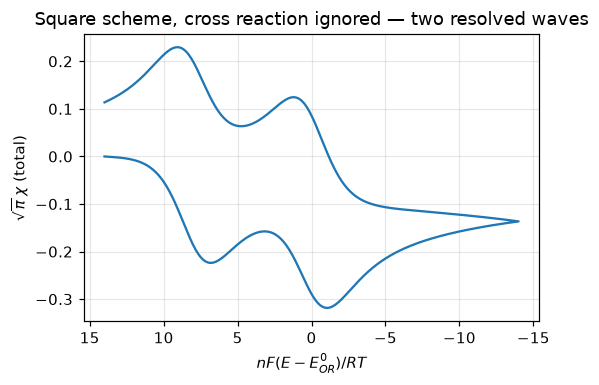

total mass per step (should be constant = 1): 1.0000000000 .. 1.0000000000


In [2]:
# Two resolved couples (dE_AB = 8 RT/nF apart), first-order interconversion only.
p_ign = sq.SquareParams(
    upper_limit=14.0, lower_limit=14.0, dE_AB=8.0, n=601, D_M=0.9,
    k_plus1=0.04, k_minus1=0.04, k_plus2=0.04, k_minus2=0.04,
    kcf=0.0, kcb=0.0, bulk=np.array([1.0, 0.0, 0.0, 0.0]))
res_ign = sq.simulate_square_cross_ignored(p_ign)

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.plot(res_ign.potential, res_ign.current, color="C0")
ax.set_xlabel(r"$nF(E-E^0_{OR})/RT$"); ax.set_ylabel(r"$\sqrt{\pi}\,\chi$ (total)")
ax.set_title("Square scheme, cross reaction ignored — two resolved waves")
ax.invert_xaxis(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()
print("total mass per step (should be constant = 1):",
      f"{sq.total_mass(res_ign.c).min():.10f} .. {sq.total_mass(res_ign.c).max():.10f}")

## 3. Solver 2 — linearised cross reaction

Now switch the cross reaction on. Writing $c^{k+1}=c^{k}+\delta c$ and dropping the
second-order product $\delta c_\mathrm{O}\,\delta c_\mathrm{B}$ (and its partners)
leaves a system that is linear in $\delta c$: the cross-rate partial derivatives,
evaluated at the *previous* time level, go into the matrix block, and the explicit
bilinear rate goes onto the right-hand side (Honeychurch's `SquareRxnExp2.nb`
`yVar`/`vect`). Still one banded solve per step.

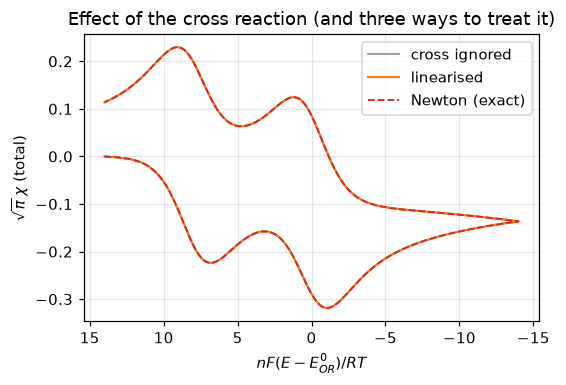

Newton iterations per step: max = 3 , mean = 3.00


In [3]:
# Same scheme, now with a strong cross reaction switched on.
common = dict(upper_limit=14.0, lower_limit=14.0, dE_AB=8.0, n=601, D_M=0.9,
              k_plus1=0.04, k_minus1=0.04, k_plus2=0.04, k_minus2=0.04,
              kcf=0.8, kcb=0.5, bulk=np.array([1.0, 0.0, 0.0, 0.0]))
res_lin = sq.simulate_square_linearized(sq.SquareParams(**common))
res_new = sq.simulate_square_newton(sq.SquareParams(**common))

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.plot(res_ign.potential, res_ign.current, color="0.6", lw=1.2,
        label="cross ignored")
ax.plot(res_lin.potential, res_lin.current, color="C1", lw=1.4, label="linearised")
ax.plot(res_new.potential, res_new.current, color="C3", ls="--", lw=1.2,
        label="Newton (exact)")
ax.set_xlabel(r"$nF(E-E^0_{OR})/RT$"); ax.set_ylabel(r"$\sqrt{\pi}\,\chi$ (total)")
ax.set_title("Effect of the cross reaction (and three ways to treat it)")
ax.invert_xaxis(); ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()
print("Newton iterations per step: max =", int(res_new.iterations.max()),
      ", mean = %.2f" % res_new.iterations[1:].mean())

## 4. Solver 3 — Newton–Raphson on the full non-linear system

The linear approximation is only first-order accurate in $\tau$. The faithful
treatment solves $F(c^{k+1})=0$ at every step by Newton iteration. For each
interior node the residual diagonal block is

$$
F_\text{diag}(c) = (1+2D_M)\,c + K\,c + g(c) - c^k,\qquad
g = (+r,\,-r,\,-r,\,+r),
$$

and the **analytic Jacobian diagonal block** is
$(1+2D_M)I + K + \partial g/\partial c$ with
$\partial r/\partial c = (k_{cf}c_\mathrm{B},\,-k_{cb}c_\mathrm{A},\,-k_{cb}c_\mathrm{R},\,k_{cf}c_\mathrm{O})$.
The constant $-D_M I$ diffusion off-diagonals complete the banded Jacobian; each
Newton step solves $J\,\delta c = -F$ (the boundary-row residuals also drive their
own corrections). The iteration stops when $\max|\delta c|$ falls below a
tolerance — typically in 2–3 iterations.

We confirmed above that, on a moderately fine grid, the Newton and linearised
voltammograms are almost indistinguishable. They are *not* identical, and the gap
is a clean diagnostic of the linearisation error.

## 5. Validation

Three checks on the **solver**, in decreasing strength per the project policy. An honest caveat first: none of these independently pins the bimolecular **cross-reaction rate term** against an external reference — there is no closed form for it. (A) and (B) hold the cross reaction *off* or are conserved by construction, so they constrain the diffusion/coupling machinery, not the cross-term itself; the cross-reaction physics is exercised only by (C), where two independent discretisations of it (Newton vs. linearised) must converge as $\tau\to0$, reinforced by the sparse-vs-dense agreement in the Chapter 15 companion.

**(A) Reduction to a validated limit — no-reaction limit recovers the Chapter 5
reversible CV.** With all chemistry off and only the first couple present, the
four-species solver must reproduce the single-couple Nernstian CV that Chapter 5
is already validated against (to machine precision).

**(B) Per-step mass balance.** The chemistry only *interconverts* species, so the
spatially-averaged total of $\mathrm{O}+\mathrm{R}+\mathrm{A}+\mathrm{B}$ is
conserved at every time step, for all three solvers (to machine precision).

**(C) Newton vs linearised agree as the step shrinks.** Both schemes converge to
the same continuum limit, so the difference between their voltammograms must
*decrease monotonically* as $\tau\to0$ (we refine $n$).

In [4]:
# --- (A) no-reaction limit vs Chapter 5 (exact cross-check) ---
p_E = sq.SquareParams(upper_limit=8.0, lower_limit=8.0, n=401, D_M=0.45,
                      bulk=np.array([1.0, 0.0, 0.0, 0.0]))   # all chemistry off
res_E = sq.simulate_square_cross_ignored(p_E)
g = ch05.make_cv_grid(0.45, 401, lower_limit=8.0, upper_limit=8.0)
ch05.implicit_cv(g)
i05 = ch05.dimensionless_current(g)
errA = np.nanmax(np.abs(res_E.current - i05))
print(f"(A) max |square(no chem) - Chapter 5| = {errA:.2e}   [tier 2: reduction to validated limit]")
assert errA < 1e-10, "no-reaction limit must match Chapter 5 to machine precision"
print("    PASS")

(A) max |square(no chem) - Chapter 5| = 1.36e-14   [tier 2: reduction to validated limit]
    PASS


In [5]:
# --- (B) per-step mass balance for all three solvers (with full chemistry) ---
pB = dict(upper_limit=10.0, lower_limit=10.0, dE_AB=0.4, n=301, D_M=0.9,
          k_plus1=0.05, k_minus1=0.02, k_plus2=0.03, k_minus2=0.04,
          kcf=0.5, kcb=0.3, bulk=np.array([0.6, 0.0, 0.4, 0.0]))
total0 = pB["bulk"].sum()
for name, fn in [("cross-ignored", sq.simulate_square_cross_ignored),
                 ("linearised",    sq.simulate_square_linearized),
                 ("Newton",        sq.simulate_square_newton)]:
    r = fn(sq.SquareParams(**pB))
    mt = sq.total_mass(r.c)
    drift = np.max(np.abs(mt - total0))
    print(f"(B) {name:14s}: max |total - {total0:.2f}| = {drift:.2e}")
    assert drift < 1e-10, f"{name} violates mass balance"
print("    PASS  [tier 3: conservation / self-consistency]")

(B) cross-ignored : max |total - 1.00| = 6.26e-14


(B) linearised    : max |total - 1.00| = 6.88e-14


(B) Newton        : max |total - 1.00| = 7.13e-14
    PASS  [tier 3: conservation / self-consistency]


(C) n= 201:  max|linearised - Newton| = 4.507e-07
(C) n= 401:  max|linearised - Newton| = 2.225e-07
(C) n= 801:  max|linearised - Newton| = 1.129e-07
    PASS  [tier 3: convergence to the common continuum limit]


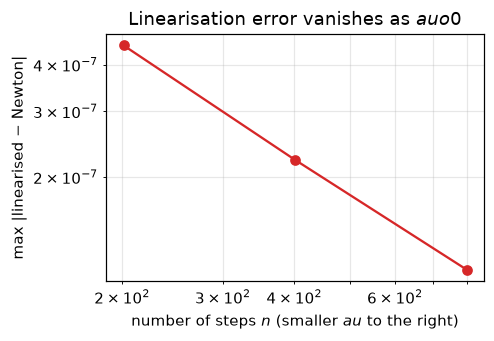

In [6]:
# --- (C) Newton vs linearised agree, and the gap shrinks as tau -> 0 ---
pC = dict(upper_limit=10.0, lower_limit=10.0, dE_AB=0.4, D_M=0.9,
          k_plus1=0.04, k_minus1=0.02, k_plus2=0.03, k_minus2=0.01,
          kcf=0.4, kcb=0.25, bulk=np.array([0.6, 0.0, 0.4, 0.0]))
n_list = [201, 401, 801]
gaps = []
for n in n_list:
    rl = sq.simulate_square_linearized(sq.SquareParams(n=n, **pC))
    rn = sq.simulate_square_newton(sq.SquareParams(n=n, **pC))
    gaps.append(np.nanmax(np.abs(rl.current - rn.current)))
gaps = np.array(gaps)
for n, gp in zip(n_list, gaps):
    print(f"(C) n={n:>4}:  max|linearised - Newton| = {gp:.3e}")
assert np.all(np.diff(gaps) < 0), "linearisation error must shrink as tau -> 0"
print("    PASS  [tier 3: convergence to the common continuum limit]")

fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.loglog(n_list, gaps, "o-", color="C3")
ax.set_xlabel("number of steps $n$ (smaller $\tau$ to the right)")
ax.set_ylabel("max |linearised $-$ Newton|")
ax.set_title("Linearisation error vanishes as $\tau\to0$")
ax.grid(alpha=0.3, which="both"); fig.tight_layout(); plt.show()

## 6. Summary

The square scheme exercises the full machinery of Chapter 13 on a four-species,
genuinely non-linear system:

* The block-tridiagonal/banded structure of Rudolph's method scales unchanged from
  the EC mechanism to four species — only the block size grows to $4\times4$.
* The **cross reaction** is the only non-linear ingredient. Three strategies trade
  cost against fidelity: ignoring it (linear, cheapest), linearising it about the
  last step (linear, first-order accurate in $\tau$), or solving it exactly by
  **Newton–Raphson** with the analytic Jacobian (a handful of iterations per step).
* The Newton and linearised voltammograms converge to the same curve as $\tau\to0$;
  the linearisation error is a clean, monotonically-vanishing diagnostic.
* All three solvers conserve total mass per step to machine precision, and all
  reduce to the validated Chapter 5 reversible CV when the chemistry is switched off.

The implementation lives in `serm/ch13_square_scheme.py`
(`simulate_square_cross_ignored`, `simulate_square_linearized`,
`simulate_square_newton`).

<!-- nav-footer -->

---

[← Chapter 13 — Coupled Chemical Reactions](../13_coupled_chemical_reactions.ipynb)

[Contents (README)](../../README.md)